check versioning

In [23]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.2.0+cu121
CUDA version: 12.1


In [25]:
from pathlib import Path
import json

annotation_dir = Path("C:\\Users\\WA\\Desktop\\badanie\\syncity3D\\COCO_DATASETS\\D1_2\\annotations\\SMOOTHED")

annotations_train_m1_path = annotation_dir / "instances_train_smooth_m1.json"
annotations_val_m1_path = annotation_dir / "instances_val_smooth_m1.json"

with open (annotations_train_m1_path, mode="r") as f:
    annotations_train_m1 = json.load(f)

with open (annotations_val_m1_path, mode="r") as f:
    annotations_val_m1 = json.load(f)

print(len(annotations_train_m1["categories"]))
print(annotations_train_m1["categories"])
print(len(annotations_val_m1["categories"]))
print(annotations_val_m1["categories"])

21
[{'id': 1000, 'name': 'Facade', 'supercategory': 'object'}, {'id': 0, 'name': '0', 'supercategory': 'object'}, {'id': 1, 'name': '1', 'supercategory': 'object'}, {'id': 2, 'name': '2', 'supercategory': 'object'}, {'id': 3, 'name': '3', 'supercategory': 'object'}, {'id': 4, 'name': '4', 'supercategory': 'object'}, {'id': 5, 'name': '5', 'supercategory': 'object'}, {'id': 6, 'name': '6', 'supercategory': 'object'}, {'id': 7, 'name': '7', 'supercategory': 'object'}, {'id': 8, 'name': '8', 'supercategory': 'object'}, {'id': 9, 'name': '9', 'supercategory': 'object'}, {'id': 10, 'name': '10', 'supercategory': 'object'}, {'id': 11, 'name': '11', 'supercategory': 'object'}, {'id': 12, 'name': '12', 'supercategory': 'object'}, {'id': 13, 'name': '13', 'supercategory': 'object'}, {'id': 14, 'name': '14', 'supercategory': 'object'}, {'id': 15, 'name': '15', 'supercategory': 'object'}, {'id': 16, 'name': '16', 'supercategory': 'object'}, {'id': 17, 'name': '17', 'supercategory': 'object'}, {'i

In [6]:
!pip install "setuptools<70.0.0"

   ---------------------------------------- 0.0/894.6 kB ? eta -:--:--
   ---------------------------------------- 894.6/894.6 kB 6.7 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1


In [26]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random


# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

In [27]:
from detectron2.data import DatasetCatalog, MetadataCatalog


datasets_to_remove = ["E1_M1_dataset_train", "E1_M1_dataset_val"]

for dataset_name in datasets_to_remove:
    if dataset_name in DatasetCatalog:
        del DatasetCatalog[dataset_name]


    if dataset_name in MetadataCatalog:
        del MetadataCatalog[dataset_name]

print("ok")

ok


In [28]:
from detectron2.data.datasets import register_coco_instances

IMAGES_DIR = Path("C:\\Users\\WA\\Desktop\\badanie\\syncity3D\\COCO_DATASETS\D1_2\\images")
train_images_dir = IMAGES_DIR / "train"
val_images_dir = IMAGES_DIR / "val"

register_coco_instances("E1_M1_dataset_train", {}, annotations_train_m1_path, train_images_dir)
register_coco_instances("E1_M1_dataset_val", {}, annotations_val_m1_path, val_images_dir)

WARNING [05/21 15:18:37 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[05/21 15:18:37 d2.data.datasets.coco]: Loaded 334 images in COCO format from C:\Users\WA\Desktop\badanie\syncity3D\COCO_DATASETS\D1_2\annotations\SMOOTHED\instances_train_smooth_m1.json


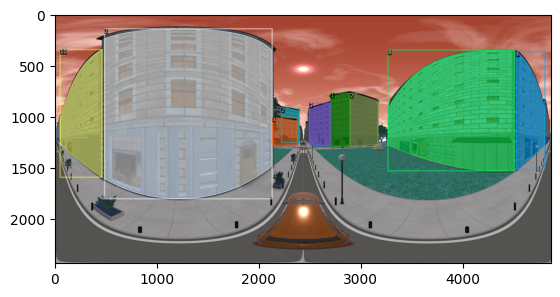

In [29]:
import random
import cv2
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.utils.visualizer import Visualizer
import matplotlib.pyplot as plt

dataset_name = "E1_M1_dataset_train"

# registry dicts build by detectron
my_metadata = MetadataCatalog.get(dataset_name)
dataset_dicts = DatasetCatalog.get(dataset_name)


for d in random.sample(dataset_dicts, min(3, len(dataset_dicts))):
    img = cv2.imread(d["file_name"])

    # Skala 0.5 lub 1.0 w zależności od tego, jak duże masz oryginalne obrazy
    visualizer = Visualizer(img[:, :, ::-1], metadata=my_metadata, scale=0.8)

    out = visualizer.draw_dataset_dict(d)

    plt.imshow(out.get_image()[:, :, ::-1])

In [33]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [34]:
from detectron2.engine import DefaultTrainer

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("E1_M1_dataset_train")
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 32  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.00025  # pick a good LR
cfg.SOLVER.MAX_ITER = 300    # 300 iterations seems good enough for this toy dataset; you will need to train longer for a practical dataset
cfg.SOLVER.STEPS = []        # do not decay learning rate
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 32   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(annotations_train_m1["categories"])  #. (see https://detectron2.readthedocs.io/tutorials/datasets.html#update-the-config-for-new-datasets)
# NOTE: this config means the number of classes, but a few popular unofficial tutorials incorrect uses num_classes+1 here.
cfg.INPUT.MASK_FORMAT = "bitmask"


cfg.OUTPUT_DIR = "C:\\Users\\WA\\Desktop\\badanie\\syncity3D\\EKSPERYMENT\\E2_jakis\\output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg) 
trainer.resume_or_load(resume=False)
trainer.train()

[05/21 15:32:49 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (22, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (22,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (84, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (84,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (21, 256, 1, 

[05/21 15:32:49 d2.engine.train_loop]: Starting training from iteration 0
ERROR [05/21 15:34:20 d2.engine.train_loop]: Exception during training:
Traceback (most recent call last):
  File "c:\Users\WA\miniconda3\envs\DetectronTest\Lib\site-packages\detectron2\engine\train_loop.py", line 152, in train
    self.run_step()
  File "c:\Users\WA\miniconda3\envs\DetectronTest\Lib\site-packages\detectron2\engine\defaults.py", line 530, in run_step
    self._trainer.run_step()
  File "c:\Users\WA\miniconda3\envs\DetectronTest\Lib\site-packages\detectron2\engine\train_loop.py", line 307, in run_step
    loss_dict = self.model(data)
                ^^^^^^^^^^^^^^^^
  File "c:\Users\WA\miniconda3\envs\DetectronTest\Lib\site-packages\torch\nn\modules\module.py", line 1511, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\WA\miniconda3\envs\DetectronTest\Lib\site-packages\torch\nn\modules\module.py", line 1520, in _call_im

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.72 GiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 17.24 GiB is allocated by PyTorch, and 682.68 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)